## Imports

In [12]:
import zipfile as zf
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [13]:
zip_train = "mnist_img_train.txt.zip"
zip_test = "mnist_img_test.txt.zip"
try: 
    with zf.ZipFile(zip_train, 'r') as files:
        files.extractall()
except FileNotFoundError: print(f"Error: {zip_train} not found")
try: 
    with zf.ZipFile(zip_test, 'r') as files2:
        files2.extractall()
except FileNotFoundError: print(f"Error: {zip_test} not found")

In [14]:
input_train = open('mnist_img_train.txt', 'r')
input_train_lines = input_train.readlines()
input_train.close()
train_x = np.array([[int (r) for r in i.split(" ")] for i in input_train_lines])

input_test = open('mnist_img_test.txt', 'r')
input_test_lines = input_test.readlines()
input_test.close()
test_x = np.array([[int (r) for r in i.split(" ")] for i in input_test_lines])

summary_psi_train = open('summary_psi_train_all.txt', 'r')
summary_psi_train_lines = summary_psi_train.readlines()
summary_psi_train.close()
train_psi = np.array([[float (r) for r in i.split(" ")] for i in summary_psi_train_lines])

summary_psi_test = open('summary_psi_test_all.txt', 'r')
summary_psi_test_lines = summary_psi_test.readlines()
summary_psi_test.close()
test_psi = np.array([[float (r) for r in i.split(" ")] for i in summary_psi_test_lines])

In [15]:
print(f"Number of columns in train_psi: {train_psi.shape[1]}")
print(f"Last column index (d=50%): {train_psi.shape[1] - 1}")

print("Number of training examples: {}".format(len(train_x)))
print("Number of testing examples: {}".format(len(test_x)))

#print(train_x.shape)

Number of columns in train_psi: 13
Last column index (d=50%): 12
Number of training examples: 60000
Number of testing examples: 10000


Training complete after 55 iterations.

MSE per epoch (training):
  Epoch   1: MSE = 1506.570394
  Epoch   2: MSE = 60.255412
  Epoch   3: MSE = 36.668246
  Epoch   4: MSE = 28.378954
  Epoch   5: MSE = 23.612997
  Epoch   6: MSE = 20.536749
  Epoch   7: MSE = 18.569773
  Epoch   8: MSE = 17.139367
  Epoch   9: MSE = 15.429685
  Epoch  10: MSE = 14.337736
  Epoch  11: MSE = 13.231279
  Epoch  12: MSE = 12.264551
  Epoch  13: MSE = 11.626401
  Epoch  14: MSE = 11.351476
  Epoch  15: MSE = 10.507806
  Epoch  16: MSE = 10.121553
  Epoch  17: MSE = 9.688984
  Epoch  18: MSE = 9.355678
  Epoch  19: MSE = 9.062457
  Epoch  20: MSE = 8.457080
  Epoch  21: MSE = 8.458579
  Epoch  22: MSE = 8.273966
  Epoch  23: MSE = 7.659584
  Epoch  24: MSE = 7.370345
  Epoch  25: MSE = 7.197840
  Epoch  26: MSE = 6.936723
  Epoch  27: MSE = 6.847274
  Epoch  28: MSE = 6.626402
  Epoch  29: MSE = 6.407581
  Epoch  30: MSE = 6.186721
  Epoch  31: MSE = 6.160175
  Epoch  32: MSE = 5.982355
  Epoch  33: MSE = 5

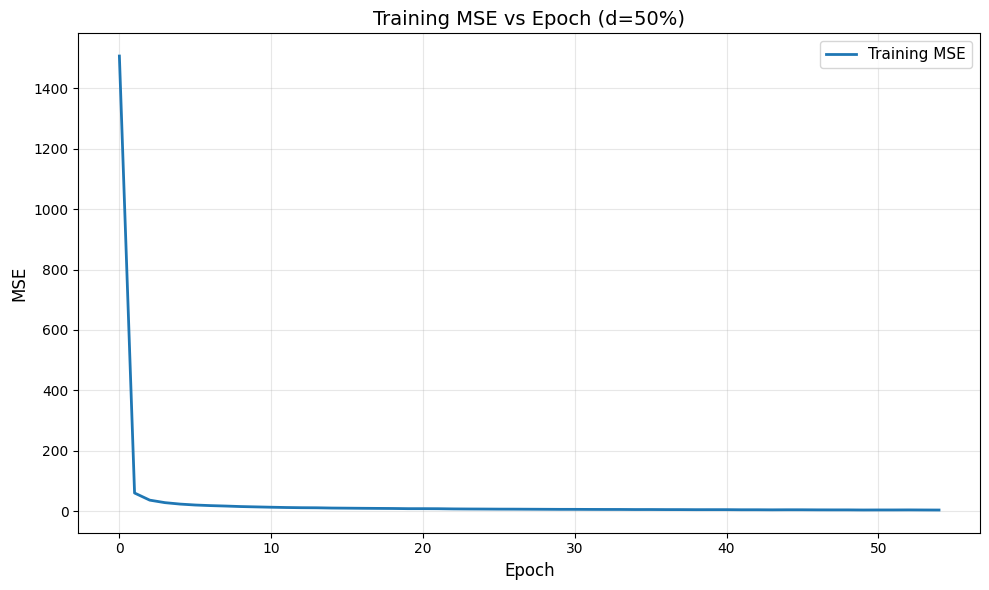


Final Mean Absolute Percentage Error (MAPE) on Test Set: 2.4016%


In [ ]:
d_50_idx = 12
train_y = train_psi[:, d_50_idx]
test_y = test_psi[:, d_50_idx]

scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

MLP_model = MLPRegressor(hidden_layer_sizes=(128,64,32), activation="relu", solver="adam", max_iter=500,
                         early_stopping=True, validation_fraction=0.1, random_state=42, verbose=False)
MLP_model.fit(train_x_scaled, train_y)
print(f"Training complete after {MLP_model.n_iter_} iterations.\n")

train_pred = MLP_model.predict(train_x_scaled)
test_pred  = MLP_model.predict(test_x_scaled)

print("MSE per epoch (training):")
for epoch, mse in enumerate(MLP_model.loss_curve_, start=1): print(f"  Epoch {epoch:3d}: MSE = {mse:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(MLP_model.loss_curve_, label='Training MSE', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Training MSE vs Epoch (d=50%)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

test_mape = np.mean(np.abs((test_y - test_pred) /test_y)) * 100
test_r2   = r2_score(test_y, test_pred)
print(f"\nFinal Mean Absolute Percentage Error (MAPE) on Test Set: {test_mape:.4f}%")

This MLP architecture uses hidden layers of 128 --> 64 --> 32 neurons from the input of 784 (28x28 flattened) bitmap values down to a single scalar strain energy output. The activation function is ReLU, the solver is Adam, the input features are standardized with the StandardScaler to prevent any features from dominating unnaturally, and early stopping is enabled with a 10% validation set split to prevent overfitting by stopping training when validation loss stops improving. A few parameters use the default SkLearn values: alpha is 0.0001, batch size is auto, the learning rate is the standard Adam starting learning rate of 0.001, and the learning rate schedule is deactivated so that it does not change during training. The MSE vs epoch curve shows how quickly the solver minimizes training error within the first few epochs, and pushes to a well converged value near the end. While the maximum number of allowed iterations was 200, the solver ran for only 55 and stopped early, meaning validation loss did not continue to decrease past epoch #55. 

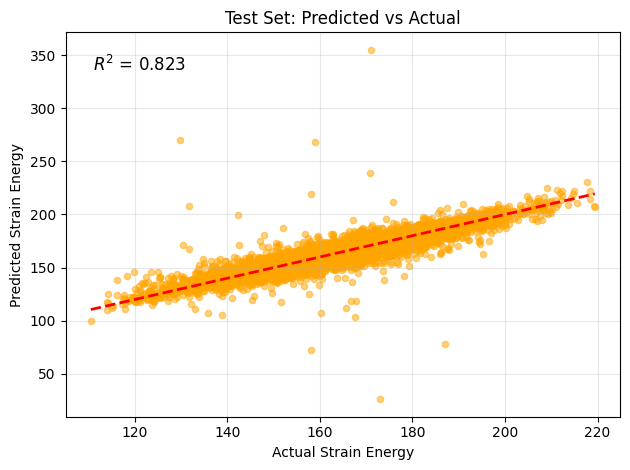

In [17]:
plt.plot()
plt.scatter(test_y, test_pred, alpha=0.5, s=20, color='orange')
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], 'r--', lw=2)
plt.xlabel('Actual Strain Energy')
plt.ylabel('Predicted Strain Energy')
plt.title('Test Set: Predicted vs Actual')
plt.grid(True, alpha=0.3)
plt.tight_layout()
test_r2 = r2_score(test_y, test_pred)
plt.text(0.05, 0.9, f'$R^2$ = {test_r2:.3f}', transform=plt.gca().transAxes, fontsize=12)
plt.show()

The true vs predicted value plot shows relatively good accuracy from the model, yielding an R^2 value of 0.823 (close to 1), which is acceptable. This MLP architecture may perform better if the hidden node sizes are made larger, but the current setup yielded a good balance between training time and performance. 

## Number 2

In [18]:
import requests
import zipfile
import io
import os

url = "https://open.bu.edu/bitstreams/c873c90c-9e58-4ee9-aca9-d456159263e6/download"

zip_name = "FEA_displacement_results_step12.zip"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
print("Status code:", response.status_code)

with open(zip_name, "wb") as f: f.write(response.content)
print("File size (MB):", os.path.getsize(zip_name) / 1e6)
with zipfile.ZipFile(zip_name, 'r') as zip_ref: zip_ref.extractall()
print("Extraction complete.")

Status code: 200
File size (MB): 385.554403
Extraction complete.


In [19]:
base_path = r"C:\Users\andyk\Downloads\FEA_displacement_results_step12"

train_disp_x = np.loadtxt(base_path + r"\summary_dispx_train_step12.txt")
train_disp_y = np.loadtxt(base_path + r"\summary_dispy_train_step12.txt")

test_disp_x = np.loadtxt(base_path + r"\summary_dispx_test_step12.txt")
test_disp_y = np.loadtxt(base_path + r"\summary_dispy_test_step12.txt")

train_dy = np.hstack([train_disp_x, train_disp_y])
test_dy = np.hstack([test_disp_x, test_disp_y])

print("train displacement (y) shape:", train_dy.shape)
print("test displacement (y) shape:", test_dy.shape)

scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

train displacement (y) shape: (60000, 1568)
test displacement (y) shape: (10000, 1568)


Training complete after 81 iterations.

Training MSE per epoch:
  Epoch   1: MSE = 1.027908
  Epoch   2: MSE = 0.077181
  Epoch   3: MSE = 0.053867
  Epoch   4: MSE = 0.043084
  Epoch   5: MSE = 0.037480
  Epoch   6: MSE = 0.032765
  Epoch   7: MSE = 0.029699
  Epoch   8: MSE = 0.027514
  Epoch   9: MSE = 0.025689
  Epoch  10: MSE = 0.023904
  Epoch  11: MSE = 0.022809
  Epoch  12: MSE = 0.021528
  Epoch  13: MSE = 0.019861
  Epoch  14: MSE = 0.019365
  Epoch  15: MSE = 0.018625
  Epoch  16: MSE = 0.018318
  Epoch  17: MSE = 0.017873
  Epoch  18: MSE = 0.017180
  Epoch  19: MSE = 0.017229
  Epoch  20: MSE = 0.016785
  Epoch  21: MSE = 0.015950
  Epoch  22: MSE = 0.015905
  Epoch  23: MSE = 0.015633
  Epoch  24: MSE = 0.014768
  Epoch  25: MSE = 0.014569
  Epoch  26: MSE = 0.013881
  Epoch  27: MSE = 0.014262
  Epoch  28: MSE = 0.014135
  Epoch  29: MSE = 0.013323
  Epoch  30: MSE = 0.013779
  Epoch  31: MSE = 0.013594
  Epoch  32: MSE = 0.013248
  Epoch  33: MSE = 0.012841
  Epoch  34:

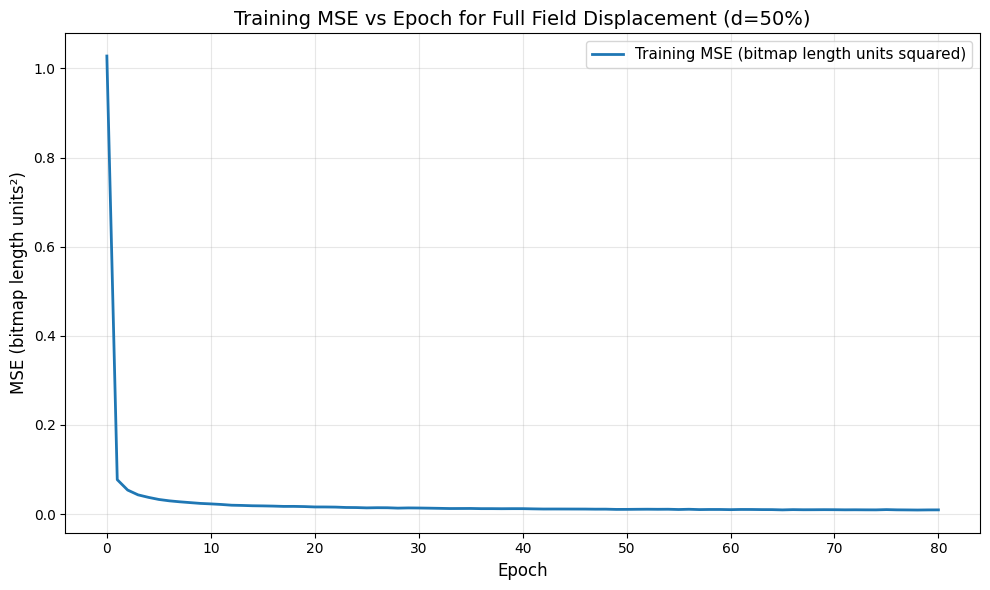


Mean Absolute Error on Test Set: 0.101412 bitmap length units


In [ ]:
mlp_disp = MLPRegressor(hidden_layer_sizes=(256, 128, 64), activation="relu", solver="adam", early_stopping=True,
                        validation_fraction=0.1, random_state=42, verbose=False)

mlp_disp.fit(train_x_scaled, train_dy)
print(f"Training complete after {mlp_disp.n_iter_} iterations.\n")

train_disp_pred = mlp_disp.predict(train_x_scaled)
test_disp_pred  = mlp_disp.predict(test_x_scaled)
print("Training MSE per epoch:")
for epoch, mse in enumerate(mlp_disp.loss_curve_, start=1): print(f"  Epoch {epoch:3d}: MSE = {mse:.6f}")
plt.figure(figsize=(10, 6))
plt.plot(mlp_disp.loss_curve_, label='Training MSE (bitmap length units squared)', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE (bitmap length units²)', fontsize=12)
plt.title('Training MSE vs Epoch for Full Field Displacement (d=50%)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
test_mae = mean_absolute_error(test_dy, test_disp_pred)
print(f"\nMean Absolute Error on Test Set: {test_mae:.6f} bitmap length units")

This model architecture is larger than that used in problem one. I wanted to try larger hidden layer sizes, which did improve accuracy at the cost of training time (as these are training on CPUs, not GPU). The model inputs are the bitmaps, and the uniaxial extension dataset at step 12 (d=50% like in number one, for consistency). The activation layer type, solver, and amount of data used for validation remain the same. The learning rate, scheduler, and alpha remain the same as the default, which works well for converging this model. THe training MSE in bitmap unit lengths is output per epoch. We see a gradual reduction in this error value as it approaches the end of training, yielding a final value of 0.009371 bitmap length units Mean Absolute Error at epoch 81 (stopped before epoch limit by the early stopping command) on the training set. On the isolated testing set, the final mean absolute error produced was 0.101412 bitmap length units. 

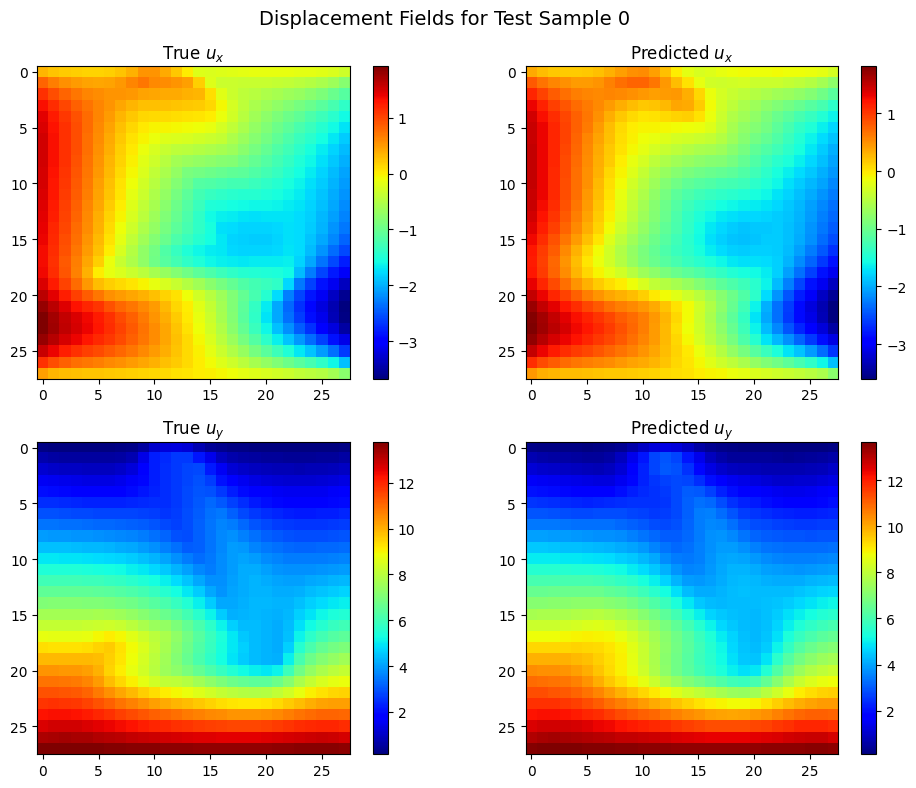

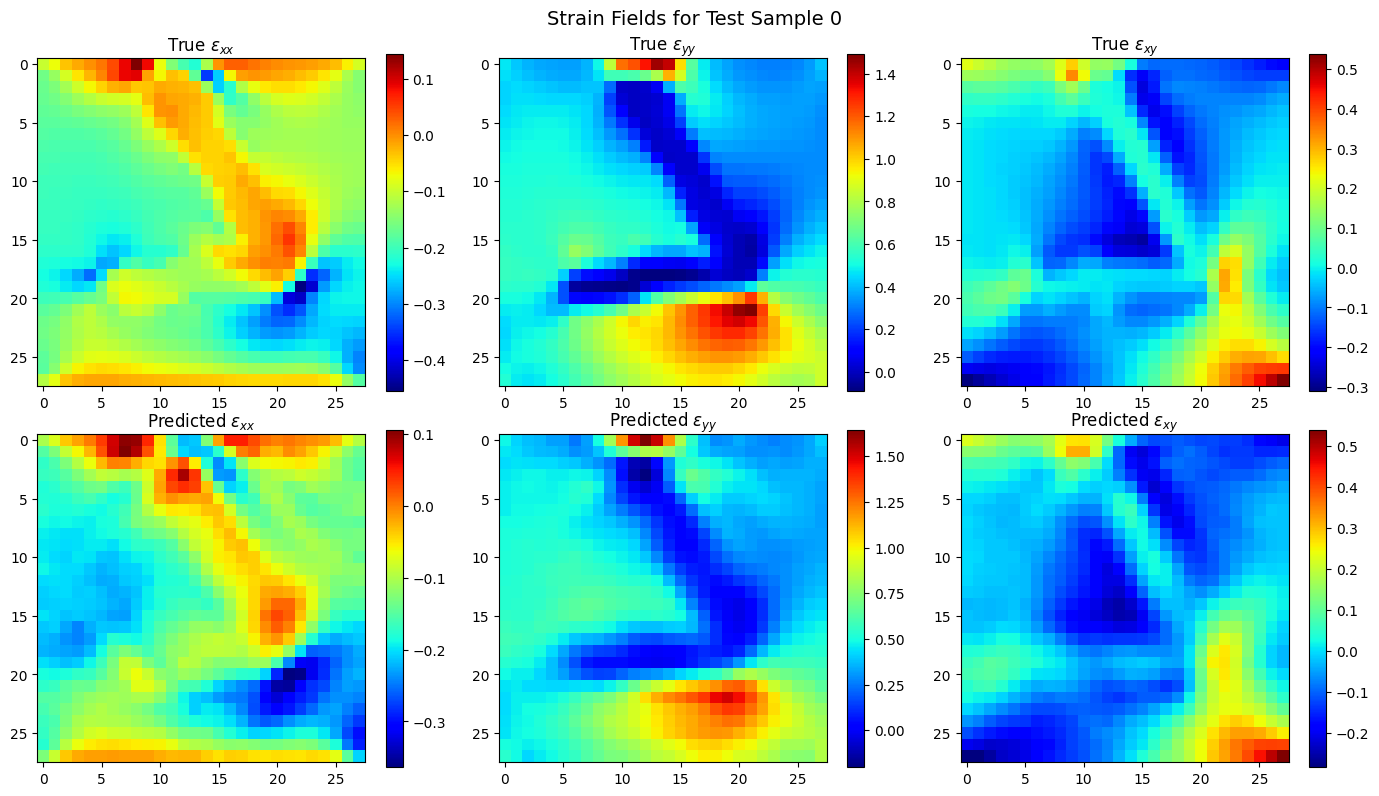

In [21]:
sample_idx = 0
n_pixels = 28 * 28 

true_ux = test_dy[sample_idx, :n_pixels].reshape(28, 28) # split flat vector into ux field
true_uy = test_dy[sample_idx, n_pixels:].reshape(28, 28) # split flat vector into uy field
pred_ux = test_disp_pred[sample_idx, :n_pixels].reshape(28, 28)
pred_uy = test_disp_pred[sample_idx, n_pixels:].reshape(28, 28)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle(f'Displacement Fields for Test Sample {sample_idx}', fontsize=14)
im = axes[0,0].imshow(true_ux, cmap='jet'); axes[0,0].set_title('True $u_x$'); plt.colorbar(im, ax=axes[0,0])
im = axes[0,1].imshow(pred_ux, cmap='jet'); axes[0,1].set_title('Predicted $u_x$'); plt.colorbar(im, ax=axes[0,1])
im = axes[1,0].imshow(true_uy, cmap='jet'); axes[1,0].set_title('True $u_y$'); plt.colorbar(im, ax=axes[1,0])
im = axes[1,1].imshow(pred_uy, cmap='jet'); axes[1,1].set_title('Predicted $u_y$'); plt.colorbar(im, ax=axes[1,1])
plt.tight_layout()
plt.show()

def compute_strain(ux, uy):
    exx = np.gradient(ux, axis=1)
    eyy = np.gradient(uy, axis=0)
    exy = 0.5 * (np.gradient(ux, axis=0) + np.gradient(uy, axis=1))
    return exx, eyy, exy
true_exx, true_eyy, true_exy = compute_strain(true_ux, true_uy)
pred_exx, pred_eyy, pred_exy = compute_strain(pred_ux, pred_uy)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(f'Strain Fields for Test Sample {sample_idx}', fontsize=14)
for col, (t, p, label) in enumerate(zip(
        [true_exx, true_eyy, true_exy],
        [pred_exx, pred_eyy, pred_exy],
        [r'$\varepsilon_{xx}$', r'$\varepsilon_{yy}$', r'$\varepsilon_{xy}$'])):
    im = axes[0, col].imshow(t, cmap='jet'); axes[0, col].set_title(f'True {label}'); plt.colorbar(im, ax=axes[0, col])
    im = axes[1, col].imshow(p, cmap='jet'); axes[1, col].set_title(f'Predicted {label}'); plt.colorbar(im, ax=axes[1, col])
plt.tight_layout()
plt.show()

The following plots use the first test sample to compare ground truth displacements and strain fields to model predictions. Code assistance was provided by Claude for formatting and setting up the axes. To convert displacement maps to strain maps, we compute direction-wise partial derivatives using np.gradient. This function approximates spatial gradients using the finite difference numerical approximation method. Displacement is the total movement of the point, while strain is a measure of deformation which affects size and shape. The displacement fields can be qualitatively compared (the colormap patterns align closely between the true and predicted for both ux and uy). The most visible discrepancy is in uy, where the low displacement blue region along the central stem appears slightly narrower in the prediction than in the ground truth, suggesting the model slightly overestimates lateral discplacement spread in that region. When converted to strain fields, predictions errors become slighlty more pronounced which is expected since taking spacial derivatives amplify any of the small local errors in the discplameent field. The exx field shows the most notable discrepancy, with several regions showing higher predicted intensity than the ground truth, indicating local overestimation of longitudinal strain. A similar but milder effect is visible in exy, where the low strain feathering flanking the high strain center member appears slightly more intense in the prediction. The eyy field appears the most accurate, only underestimating strain behavior in a few regions. It seems while the global qualitites and characteristics are captures pretty well, precise local gradients at small features may be missed.